# Assignment 2

## AI Statement

In assignment 2 I've first attempted to complete the assignment myself and then used ChatGPT as a support tool when I got stuck or wanted help checking parts of my code. In particular, I used it to troubleshoot errors, clarify some Python and SQL syntax, and improve the structure of a few solutions. I reviewed and adjusted the suggested code myself and made sure I understood the final notebook before submitting it.

## Task 0

a.) For my project I have considered using the UCI Online Retail dataset the Calendarific API as a supplementary API source.

Main dataset: UCI Online Retail   
    Source: https://archive.ics.uci.edu/dataset/352/online%2Bretail

API: Calendarific   
    Source: https://calendarific.com/




b.) The UCI Online Retail dataset contains transaction data from a online retailer. According to UCI, the dataset includes all transactions between 1 December 2010 and 9 December 2011.

The dataset has 541909 rows (transactions) and include the following variables:
1. Invoice Number
2. Stock Code
3. Description (product name)
4. Quantity
5. Date
6. Price
7. Customer ID
8. Country

In the final project, I plan to look at possible holiday effects as well as other possible patterns in consumer behavior. A possible project question could be:

Do public holidays affect online retail sales across different countries?

c.) A quick demonstration of the dataset

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [35]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Shape: (110, 8)

Columns:
Index(['date', 'symbol', 'open', 'high', 'low', 'close', 'volume',
       'adj_close'],
      dtype='object')

Data types:
date          object
symbol        object
open         float64
high         float64
low          float64
close        float64
volume       float64
adj_close    float64
dtype: object

Missing values:
date         0
symbol       0
open         0
high         0
low          0
close        0
volume       0
adj_close    0
dtype: int64


For my dataset `df.describe()` doesn't do much but I include it to demonstrate the issues with describe when using a dataset with mainly objects rather than numbers

In [5]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Keeping only rows with positive quantity and price for a cleaner initial exploration
df_clean = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

# Create sales column
df_clean["Sales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


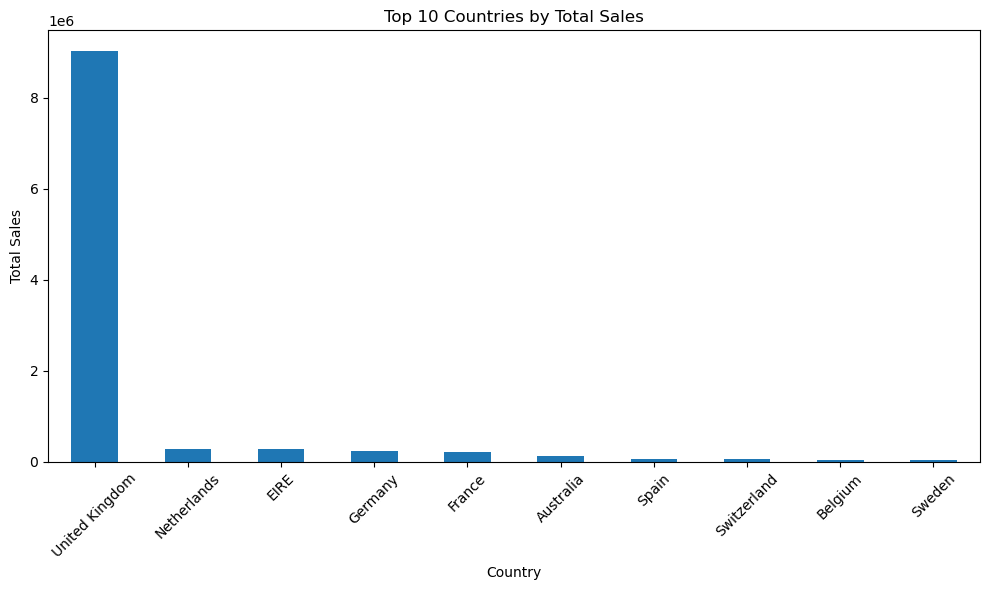

In [7]:
country_sales = (
    df_clean.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

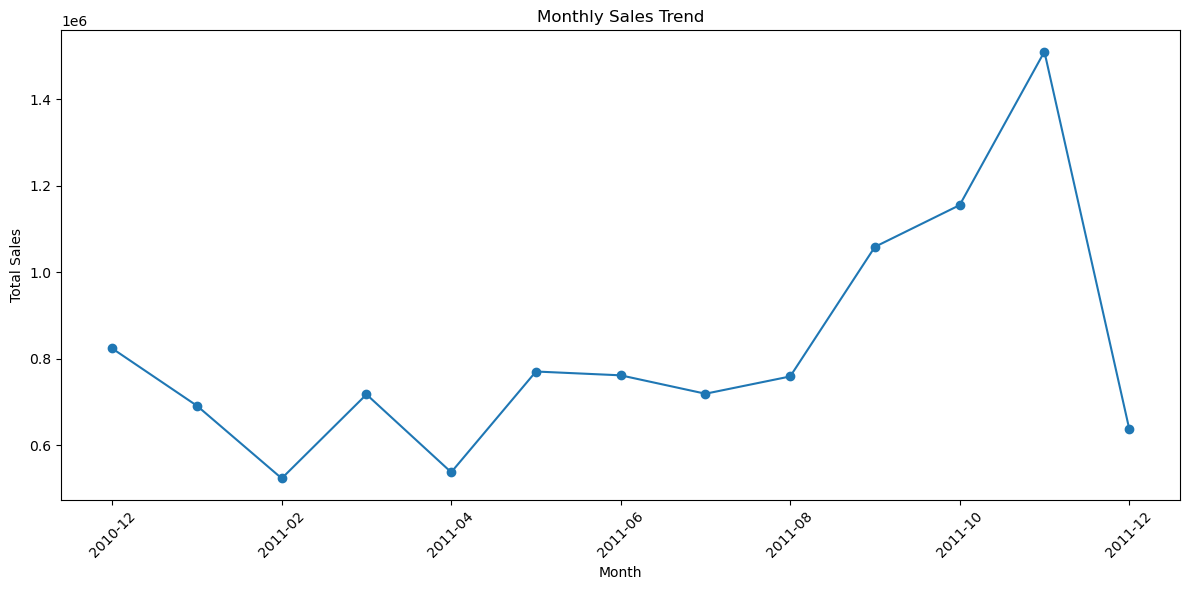

In [8]:
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = df_clean.groupby("YearMonth")["Sales"].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 1

In [2]:
#!pip install python-dotenv

In [9]:
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Get API key
api_key = os.getenv("MARKETSTACK_API_KEY")

# Print only first 5 characters for safety
print(api_key[:5] + "...")

09ed8...


## Task 2

In [27]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

In [28]:
load_dotenv(".env")
api_key = os.getenv("MARKETSTACK_API_KEY")

In [29]:
symbols = "META,AAPL,AMZN,NFLX,GOOG"

url = "https://api.marketstack.com/v2/eod"

params = {
    "access_key": api_key,
    "symbols": symbols,
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "sort": "ASC",
    "limit": 200
}

response = requests.get(url, params=params)
data_json = response.json()

In [31]:
# Convert JSON to DataFrame
df = pd.DataFrame(data_json["data"])
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df[["date", "symbol", "open", "high", "low", "close", "volume", "adj_close"]]

# Print first 5 rows
print("First 5 rows:")
display(df.head())

# Summary statistics
summary_stats = df.groupby("symbol")["close"].agg(["count", "mean", "std", "min", "max"])

# Monthly returns
returns = (
    df.sort_values(["symbol", "date"])
      .groupby("symbol")
      .agg(first_close=("close", "first"),
           last_close=("close", "last"))
)

returns["return_pct"] = ((returns["last_close"] - returns["first_close"]) / returns["first_close"]) * 100

# Combine results
results = summary_stats.join(returns).round(2)

print("\nSummary statistics and monthly returns:")
display(results)

# Best and worst performer
best_stock = returns["return_pct"].idxmax()
worst_stock = returns["return_pct"].idxmin()

best_return = round(returns.loc[best_stock, "return_pct"], 2)
worst_return = round(returns.loc[worst_stock, "return_pct"], 2)

print(f"\nBest performer in March 2026: {best_stock} ({best_return}%)")
print(f"Worst performer in March 2026: {worst_stock} ({worst_return}%)")

First 5 rows:


,date,symbol,open,high,low,close,volume,adj_close
0,2026-03-02,AAPL,262.44,266.53,260.20,264.72,41576035.0,264.72
1,2026-03-02,AMZN,204.55,209.72,203.48,208.39,43410499.0,208.39
2,2026-03-02,GOOG,302.93,308.14,301.06,306.36,21789144.0,306.36
3,2026-03-02,META,637.16,659.94,634.50,653.56,9801700.0,653.56
4,2026-03-02,NFLX,95.33,98.07,95.25,97.09,79614084.0,97.09



Summary statistics and monthly returns:


,count,mean,std,min,max,first_close,last_close,return_pct
symbol,,,,,,,,
AAPL,22,254.91,5.51,246.63,264.72,264.72,253.79,-4.13
AMZN,22,210.00,4.64,199.34,218.94,208.39,208.27,-0.06
GOOG,22,297.98,10.93,273.14,309.41,306.36,286.86,-6.37
META,22,614.99,41.31,525.72,667.73,653.56,572.13,-12.46
NFLX,22,95.08,2.51,90.92,99.17,97.09,96.15,-0.97



Best performer in March 2026: AMZN (-0.06%)
Worst performer in March 2026: META (-12.46%)


## Task 3

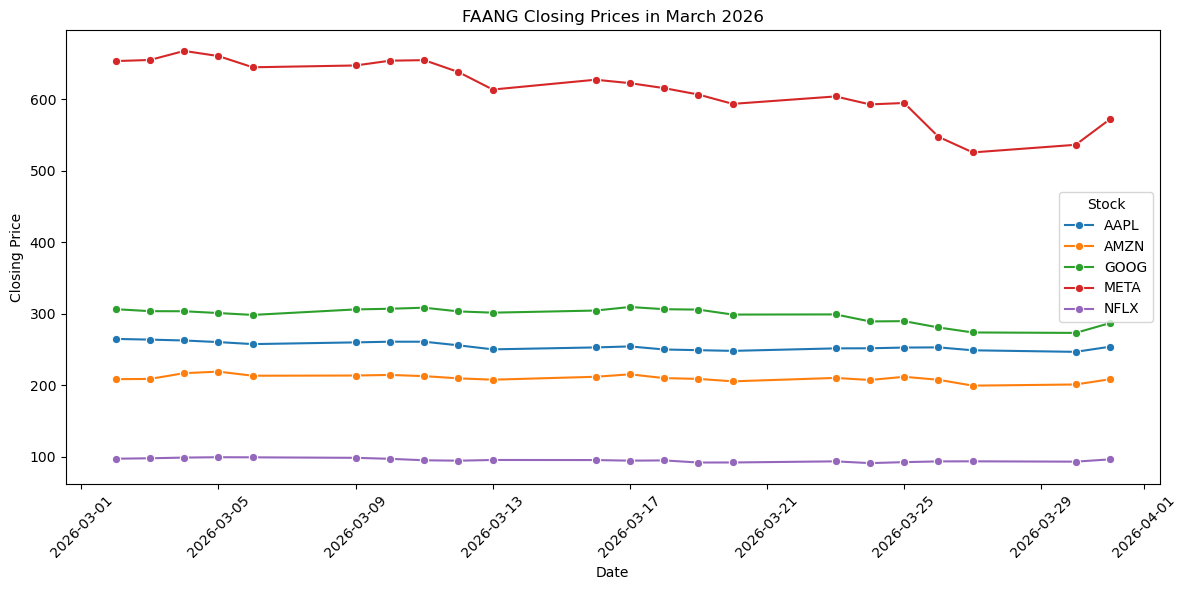

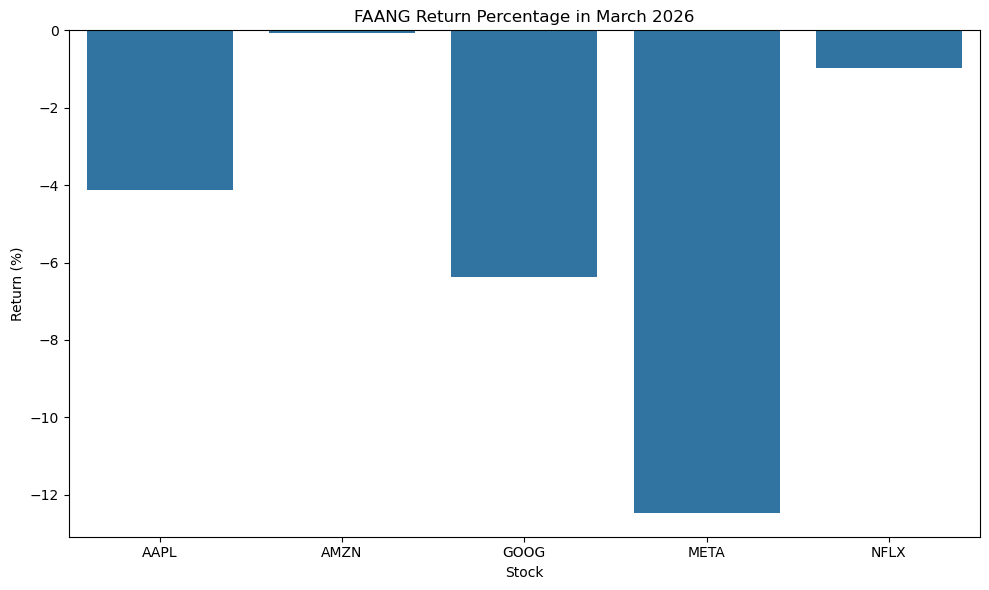

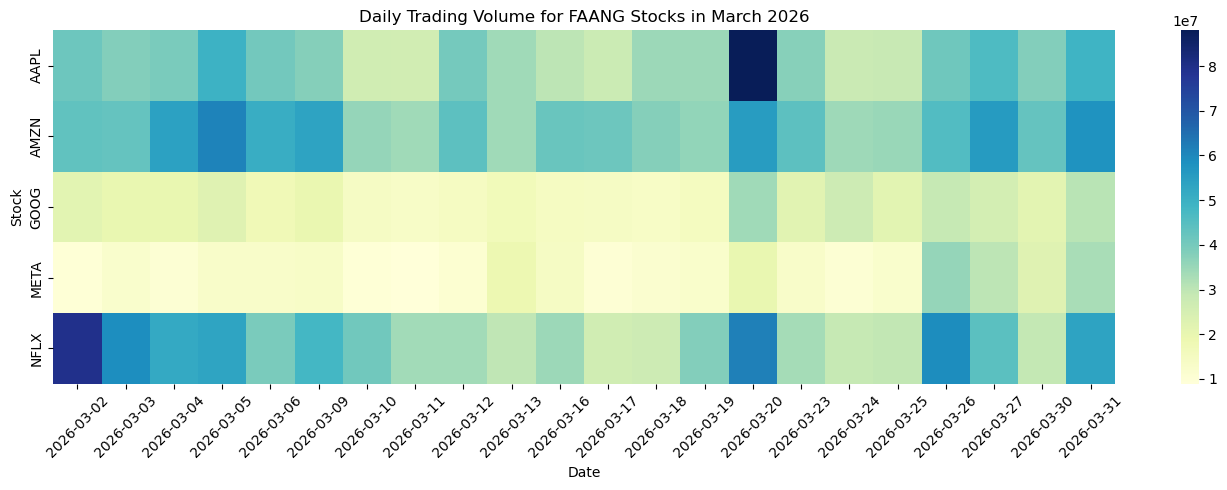

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# a) Line chart: closing prices over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="date", y="close", hue="symbol", marker="o")
plt.title("FAANG Closing Prices in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend(title="Stock")
plt.tight_layout()
plt.show()

# b) Bar plot: monthly return percentage
returns_reset = returns.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=returns_reset, x="symbol", y="return_pct")
plt.title("FAANG Return Percentage in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.show()

# c) Heatmap: daily trading volume
volume_pivot = df.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(14, 5))
sns.heatmap(volume_pivot, cmap="YlGnBu")
plt.title("Daily Trading Volume for FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 4

In [30]:
import os
import json
import pandas as pd

# Create exports folder if it does not exist
os.makedirs("exports", exist_ok=True)

# a) Export raw JSON data
with open("exports/stockdata.json", "w") as f:
    json.dump(data_json, f, indent=4)

# b) Export DataFrame as CSV
df.to_csv("exports/stockdata.csv", index=False)

print("Files exported successfully.")

Files exported successfully.


In [23]:
# c) Load JSON back
with open("exports/stockdata.json", "r") as f:
    json_loaded = json.load(f)

df_json_loaded = pd.DataFrame(json_loaded["data"])
df_json_loaded["date"] = pd.to_datetime(df_json_loaded["date"]).dt.date
df_json_loaded = df_json_loaded[["date", "symbol", "open", "high", "low", "close", "volume", "adj_close"]]

print("\nFirst 5 rows from JSON:")
display(df_json_loaded.head())

# Load CSV back
df_csv_loaded = pd.read_csv("exports/stockdata.csv")
df_csv_loaded["date"] = pd.to_datetime(df_csv_loaded["date"]).dt.date

print("\nFirst 5 rows from CSV:")
display(df_csv_loaded.head())

# Verify equality
print("\nDo the imported JSON and CSV data match?")
print(df_json_loaded.equals(df_csv_loaded))


First 5 rows from JSON:


,date,symbol,open,high,low,close,volume,adj_close
0,2026-03-02,AAPL,262.44,266.53,260.20,264.72,41576035.0,264.72
1,2026-03-02,AMZN,204.55,209.72,203.48,208.39,43410499.0,208.39
2,2026-03-02,GOOG,302.93,308.14,301.06,306.36,21789144.0,306.36
3,2026-03-02,META,637.16,659.94,634.50,653.56,9801700.0,653.56
4,2026-03-02,NFLX,95.33,98.07,95.25,97.09,79614084.0,97.09



First 5 rows from CSV:


,date,symbol,open,high,low,close,volume,adj_close
0,2026-03-02,AAPL,262.44,266.53,260.20,264.72,41576035.0,264.72
1,2026-03-02,AMZN,204.55,209.72,203.48,208.39,43410499.0,208.39
2,2026-03-02,GOOG,302.93,308.14,301.06,306.36,21789144.0,306.36
3,2026-03-02,META,637.16,659.94,634.50,653.56,9801700.0,653.56
4,2026-03-02,NFLX,95.33,98.07,95.25,97.09,79614084.0,97.09



Do the imported JSON and CSV data match?
True


## Task 5

In [22]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("northwind.db")

# a) List all tables
tables_query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""
tables = pd.read_sql_query(tables_query, conn)

print("Tables in the database:")
display(tables)

print("\nTable names:")
for table in tables["name"]:
    print(table)

# b) Products with UnitPrice above 30
query_5b = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;
"""
products_above_30 = pd.read_sql_query(query_5b, conn)

print("\nProducts with UnitPrice above 30:")
display(products_above_30)

# c) Orders shipped to Germany
query_5c = """
SELECT 
    Customers.CompanyName,
    Orders.OrderID,
    Orders.OrderDate,
    Orders.ShipCountry,
    "Order Details".UnitPrice * "Order Details".Quantity AS LineTotal
FROM Orders
JOIN Customers
    ON Orders.CustomerID = Customers.CustomerID
JOIN "Order Details"
    ON Orders.OrderID = "Order Details".OrderID
WHERE Orders.ShipCountry = 'Germany';
"""
germany_orders = pd.read_sql_query(query_5c, conn)

print("\nOrders shipped to Germany:")
display(germany_orders)

# Close the connection
conn.close()

Tables in the database:


,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products



Table names:
Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories

Products with UnitPrice above 30:


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26



Orders shipped to Germany:


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


## Task 6

Top 10 customers by number of orders:


,CompanyName,NumberOfOrders
0,QUICK-Stop,56
1,IT,40
2,Ottilies Käseladen,40
3,Frankenversand,38
4,Königlich Essen,36
5,Toms Spezialitäten,35
6,Great Lakes Food Market,35
7,Lehmanns Marktstand,34
8,B's Beverages,32
9,La maison d'Asie,31


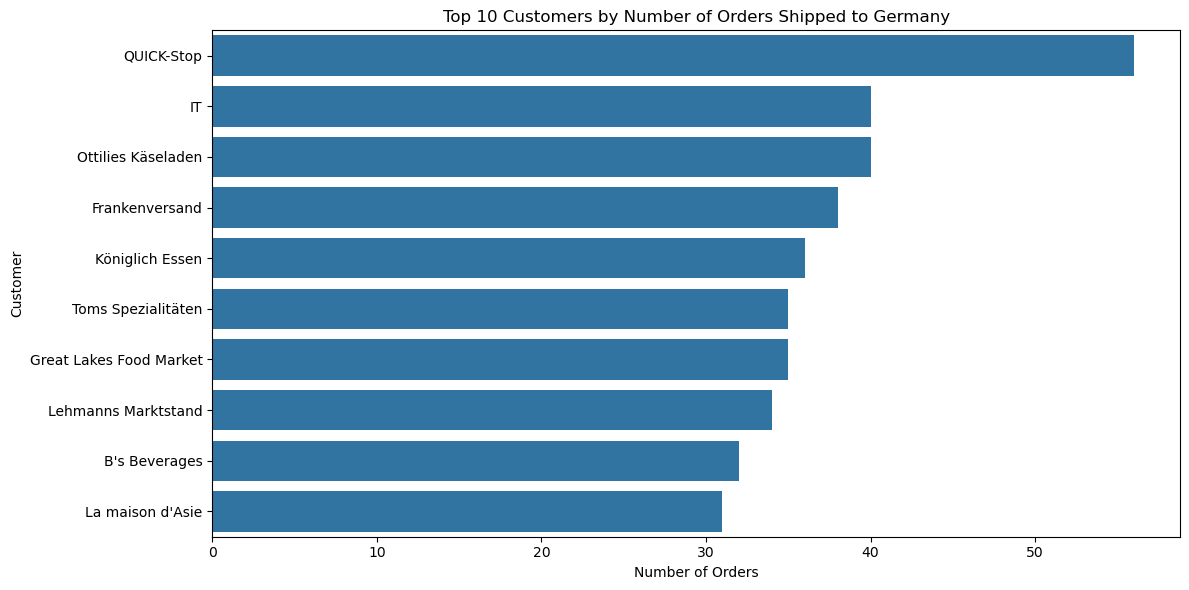


Daily total sales:


,OrderDate,DailyTotalSales
0,2016-07-05,1863.4
1,2016-07-19,1746.2
2,2016-07-29,4031.0
3,2016-08-05,2142.4
4,2016-08-09,1200.8


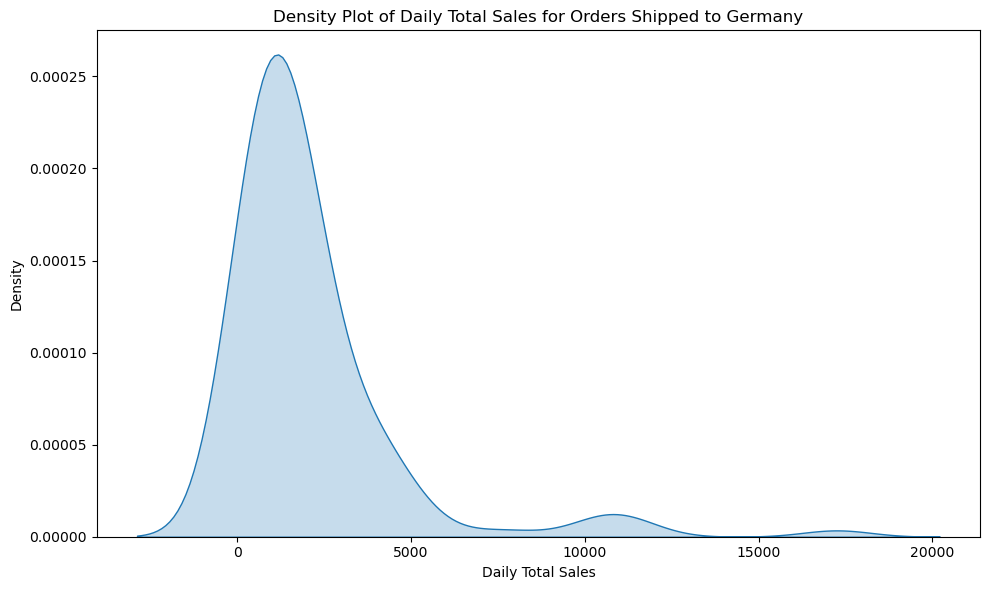


Total revenue by category:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


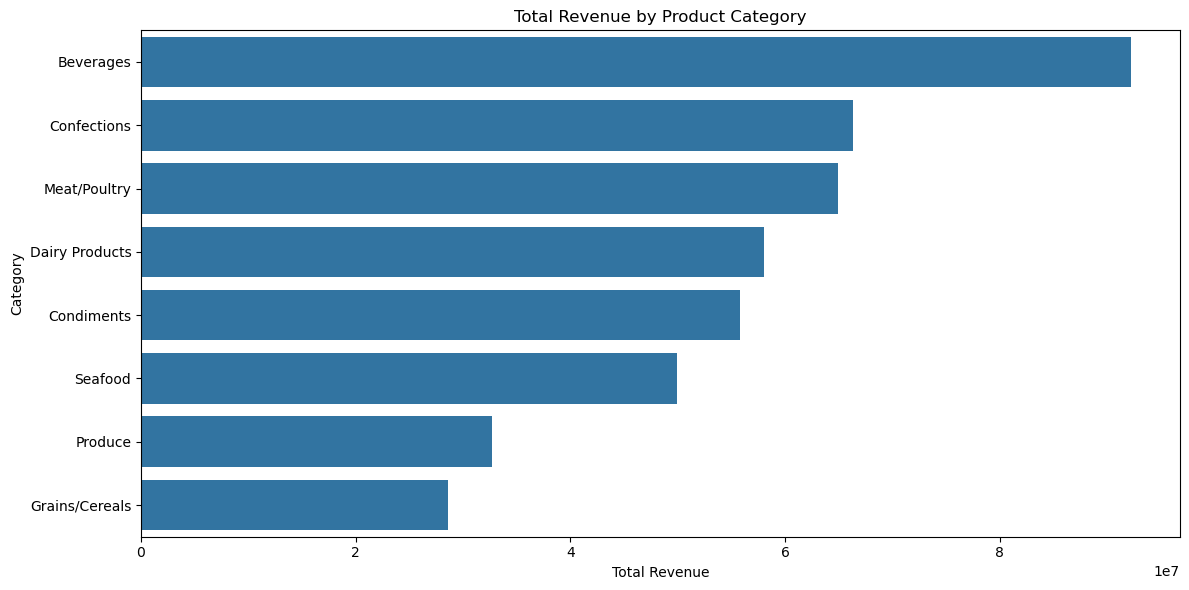

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# a) Top 10 customers by number of orders to Germany
orders_per_customer = (
    germany_orders.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="NumberOfOrders")
)

print("Top 10 customers by number of orders:")
display(orders_per_customer)

plt.figure(figsize=(12, 6))
sns.barplot(data=orders_per_customer, x="NumberOfOrders", y="CompanyName")
plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

# b) Daily total sales and KDE plot
germany_orders["OrderDate"] = pd.to_datetime(germany_orders["OrderDate"], errors="coerce")

daily_sales = (
    germany_orders.dropna(subset=["OrderDate"])
    .groupby(germany_orders.dropna(subset=["OrderDate"])["OrderDate"].dt.date)["LineTotal"]
    .sum()
    .reset_index(name="DailyTotalSales")
)

print("\nDaily total sales:")
display(daily_sales.head())

plt.figure(figsize=(10, 6))
sns.kdeplot(data=daily_sales, x="DailyTotalSales", fill=True)
plt.title("Density Plot of Daily Total Sales for Orders Shipped to Germany")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# c) Revenue by category
conn = sqlite3.connect("northwind.db")

query_6c = """
SELECT Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
JOIN Products
    ON "Order Details".ProductID = Products.ProductID
JOIN Categories
    ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName
ORDER BY TotalRevenue DESC;
"""

category_revenue = pd.read_sql_query(query_6c, conn)

print("\nTotal revenue by category:")
display(category_revenue)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, x="TotalRevenue", y="CategoryName")
plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

conn.close()

## Task 7

In [17]:
import sqlite3
import pandas as pd
import time

conn = sqlite3.connect("northwind.db")

# a) Full tables into DataFrames
products_query = "SELECT * FROM Products;"
categories_query = "SELECT * FROM Categories;"

products_df = pd.read_sql_query(products_query, conn)
categories_df = pd.read_sql_query(categories_query, conn)

print("First 5 rows of Products:")
display(products_df.head())

print("\nFirst 5 rows of Categories:")
display(categories_df.head())

# b) Inner join in pandas on CategoryID
products_categories_join = pd.merge(
    products_df,
    categories_df,
    on="CategoryID",
    how="inner"
)

print("\nFirst 5 rows of the joined DataFrame:")
display(products_categories_join.head())

# c) Compare SQL vs pandas

# SQL approach
sql_query = """
SELECT
    Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
JOIN Products
    ON "Order Details".ProductID = Products.ProductID
JOIN Categories
    ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName
ORDER BY TotalRevenue DESC;
"""

start_sql = time.time()
sql_result = pd.read_sql_query(sql_query, conn)
end_sql = time.time()
sql_time = end_sql - start_sql

print("\nSQL result:")
display(sql_result)
print(f"\nSQL execution time: {sql_time:.6f} seconds")

# Python/pandas approach
start_py = time.time()

order_details_df = pd.read_sql_query('SELECT * FROM "Order Details";', conn)
products_df = pd.read_sql_query('SELECT * FROM Products;', conn)
categories_df = pd.read_sql_query('SELECT * FROM Categories;', conn)

merged_df = pd.merge(order_details_df, products_df, on="ProductID", how="inner")
merged_df = pd.merge(merged_df, categories_df, on="CategoryID", how="inner")

merged_df["Revenue"] = merged_df["UnitPrice_x"] * merged_df["Quantity"]

python_result = (
    merged_df.groupby("CategoryName", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "TotalRevenue"})
    .sort_values("TotalRevenue", ascending=False)
)

end_py = time.time()
python_time = end_py - start_py

print("\nPython/pandas result:")
display(python_result)
print(f"\nPython execution time: {python_time:.6f} seconds")

# Comparison
if sql_time < python_time:
    print("\nSQL was faster.")
elif python_time < sql_time:
    print("\nPython/pandas was faster.")
else:
    print("\nBoth took the same amount of time.")

conn.close()

First 5 rows of Products:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1



First 5 rows of Categories:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...



First 5 rows of the joined DataFrame:


...


SQL result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55



SQL execution time: 0.799109 seconds

Python/pandas result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
2,Confections,66347544.94
5,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
1,Condiments,55802774.45
7,Seafood,49931965.52
6,Produce,32706403.90
4,Grains/Cereals,28573512.55



Python execution time: 1.622191 seconds

SQL was faster.


The outputs from SQL and pandas are identical in terms of category revenues, which confirms that the pandas implementation correctly replicated the SQL logic from Task 6c. In this case, SQL was faster than pandas, likely because the database engine handled the joins and aggregation more efficiently before returning the final result.

In [8]:
import pandas as pd

# Original datasets
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

# a) Wide to long
print("Original wide_data:")
print(wide_data)

wide_to_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("\nwide_data converted to long format:")
display(wide_to_long)

# b) Long to wide
print("\nOriginal long_data:")
display(long_data)

long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).reset_index()

print("\nlong_data converted to wide format:")
print(long_to_wide)

# c) Convert back to original wide format
long_back_to_wide = wide_to_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

long_back_to_wide.columns.name = None
long_back_to_wide = long_back_to_wide[["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]]

print("Original wide_data:")
display(wide_data)
print("\nConverted back to original wide format:")
display(long_back_to_wide)

# c) Convert back to original long format
wide_back_to_long = long_to_wide.melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
).sort_values(["month", "product"]).reset_index(drop=True)

print("\nOriginal long_data:")
display(long_data)
print("\nConverted back to original long format:")
display(wide_back_to_long)

Original wide_data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

wide_data converted to long format:
       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500

Original long_data:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

long_data converted to wide format:
product month  Laptop  Phone
0         Feb      50    110
1         Jan      45    120
2   